In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle



In [4]:
plt.figure(figsize=(10,6))
sns.set (style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [5]:
df=pd.read_csv("/content/demand_forecasting.csv")

In [6]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [7]:
df["Epidemic"].value_counts()

,count
Epidemic,
0,60800
1,15200


In [8]:
df.dtypes

,0
Date,object
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [9]:
df["Date"]=pd.to_datetime(df["Date"])

In [10]:
df.dtypes

,0
Date,datetime64[ns]
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [12]:
df.isna().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [15]:
df.describe(include="object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [16]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Day"]=df["Date"].dt.day
df["Weekday"]=df["Date"].dt.day_name()

In [17]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [18]:
df["Discounted Price"]=df["Price"] * (1-df["Discount"]/100)

In [19]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410


In [20]:
df["Sell Through Rate"]=df["Units Sold"]/ df["Inventory Level"]

In [21]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [22]:
df["Sell Through Rate"].describe()

,Sell Through Rate
count,75594.000000
mean,0.437580
std,0.298007
min,0.003150
25%,0.190807
50%,0.350475
75%,0.642276
max,1.000000


In [23]:
df.groupby("Category")["Demand"].agg(["mean","sum","std"]).sort_values(by="sum",ascending=False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [24]:
df.groupby(["Region","Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [25]:
df.groupby("Promotion")["Demand"].mean()

,Demand
Promotion,
0,95.026843
1,123.269400


In [26]:
pd.pivot_table(df,values="Demand", index="Month", columns="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


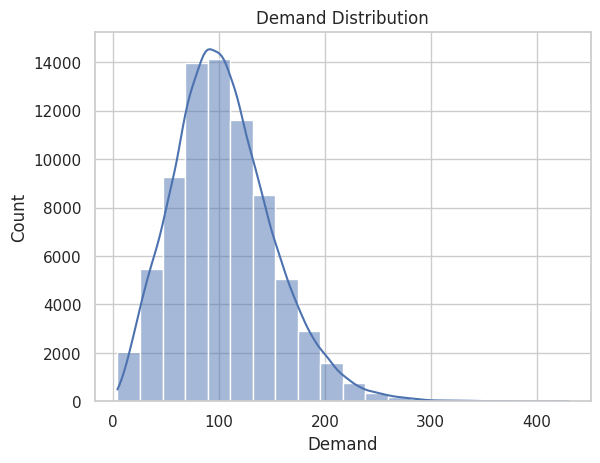

In [27]:
sns.histplot(df["Demand"],bins=20,kde=True)
plt.title("Demand Distribution")
plt.show()

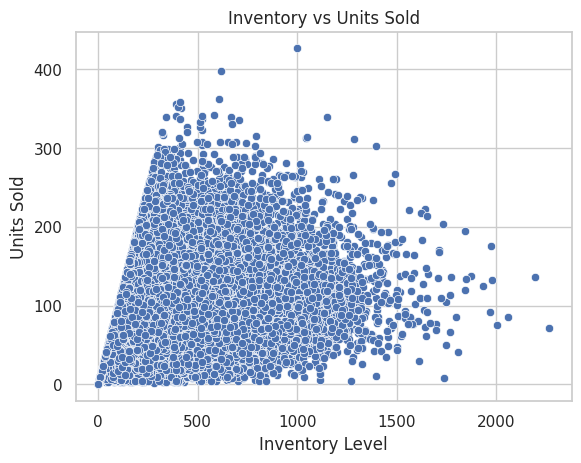

In [28]:
sns.scatterplot(data=df, x ="Inventory Level", y="Units Sold")
plt.title("Inventory vs Units Sold")
plt.show()

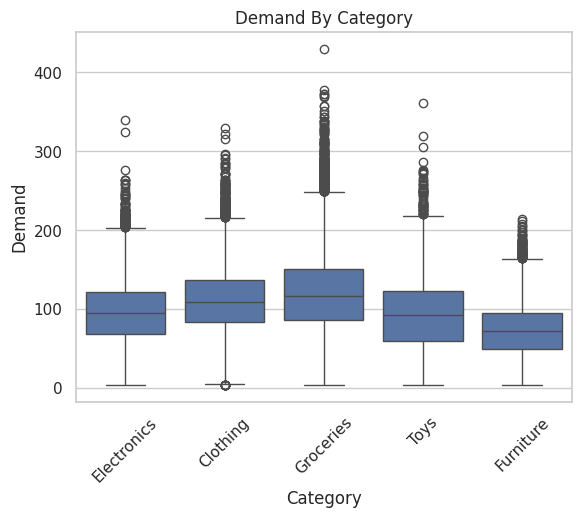

In [29]:
sns.boxplot(data=df, x="Category", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand By Category")
plt.show()

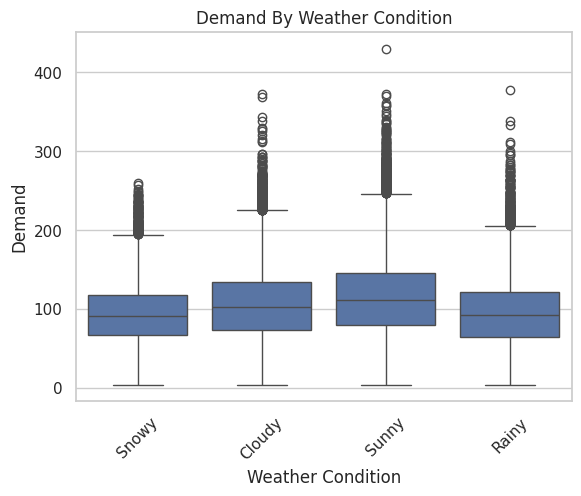

In [30]:
sns.boxplot(data=df, x="Weather Condition", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand By Weather Condition")
plt.show()

In [31]:
monthly_demand=df.groupby("Month")["Demand"].mean()

In [32]:
monthly_demand

,Demand
Month,
1,106.040000
2,92.882500
3,113.613871
4,92.816667
5,86.521129
6,117.346000
7,101.561613
8,119.803387
9,107.431500


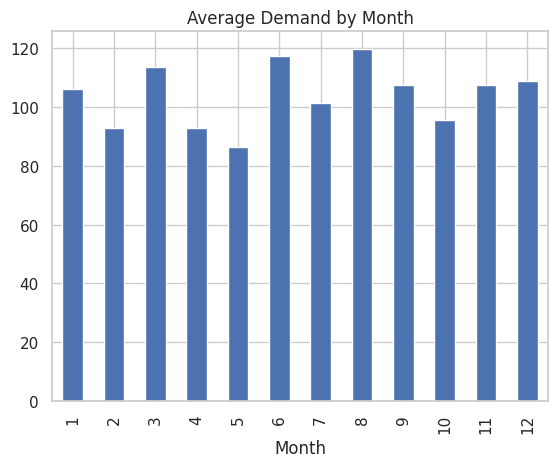

In [33]:
monthly_demand.plot(kind="bar")
plt.title("Average Demand by Month")
plt.show()

In [34]:
daily_demand=df.groupby("Date")["Demand"].sum()
daily_demand

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724
...,...
2024-01-26,11182
2024-01-27,11540
2024-01-28,11440


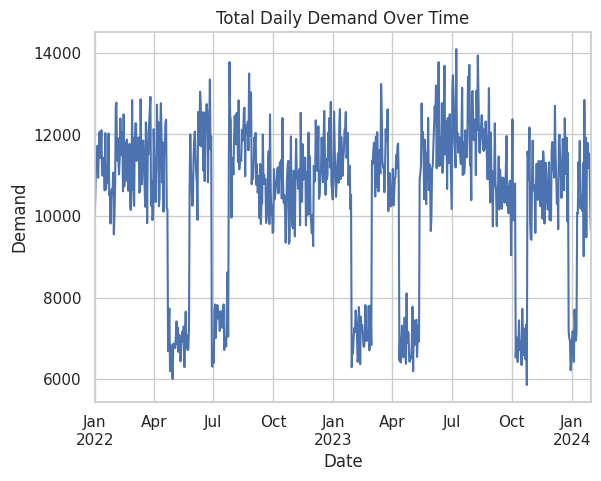

In [35]:
daily_demand.plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

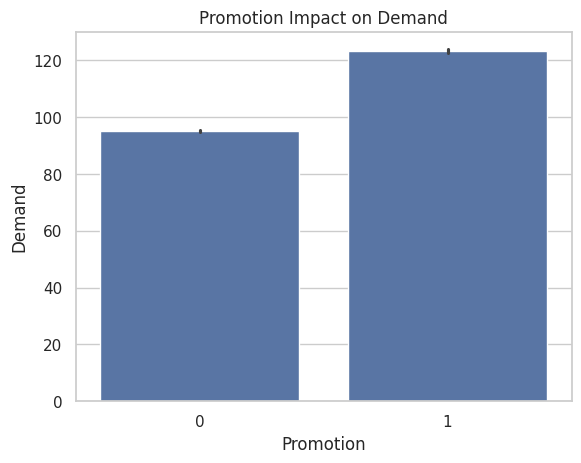

In [36]:
sns.barplot(data=df, x="Promotion", y="Demand")
plt.title("Promotion Impact on Demand")
plt.show()

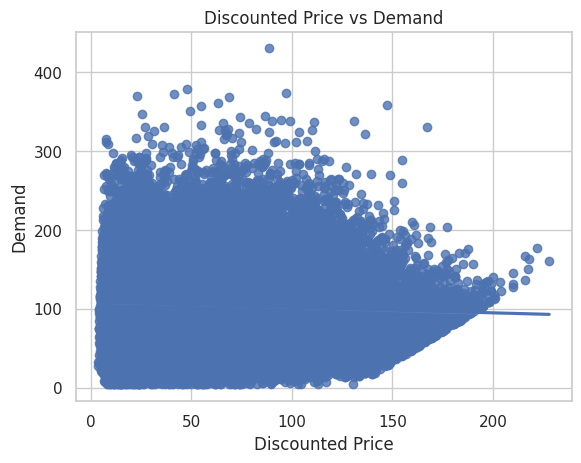

In [37]:
sns.regplot(data=df, x="Discounted Price", y="Demand")
plt.title("Discounted Price vs Demand")
plt.show()

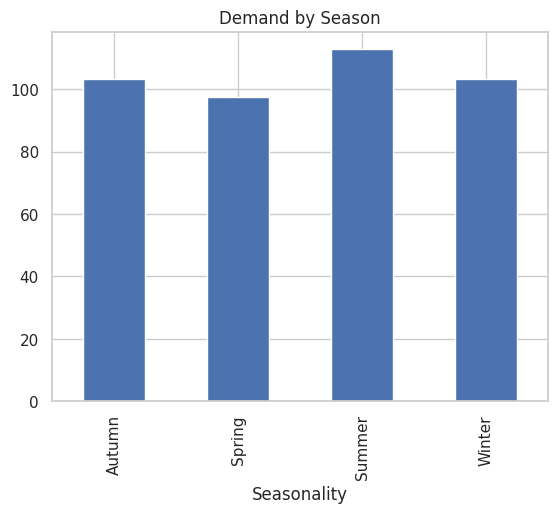

In [38]:
df.groupby("Seasonality")["Demand"].mean().plot(kind="bar", title="Demand by Season")
plt.show()

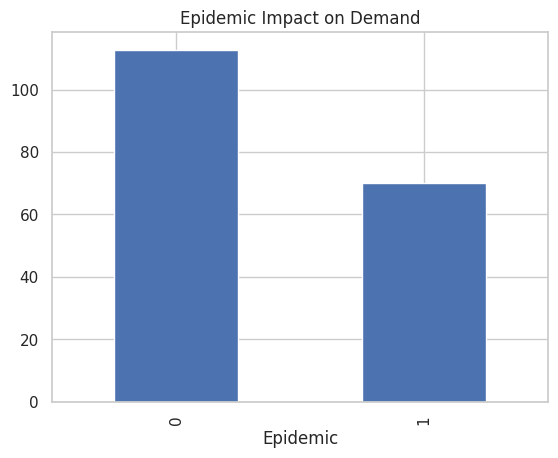

In [39]:
df.groupby("Epidemic")["Demand"].mean().plot(kind="bar", title="Epidemic Impact on Demand")
plt.show()

In [40]:
df.to_csv("preprocessed_demand_forecasting_data.csv")

In [41]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor
import pickle

In [42]:
df=pd.read_csv("/content/demand_forecasting.csv")

In [43]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [44]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [45]:
features=[
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"

]

In [46]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [47]:
target="Demand"

In [48]:
X=df[features].copy()

In [49]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [50]:
Y=df[target]

In [51]:
Y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


In [52]:
label_encoders={}
categorical_cols=X.select_dtypes(include="object").columns

In [53]:
categorical_cols

Index(['Category'], dtype='object')

In [54]:
for col in categorical_cols:
  le=LabelEncoder()
  X[col]=le.fit_transform(X[col])
  label_encoders[col]=le

In [55]:
label_encoders

{'Category': LabelEncoder()}

In [56]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2)

In [57]:
xgb=XGBRegressor(objective="reg:squarederror", n_jobs=-1)

In [58]:
param_dict={
    "n_estimators":[200, 300, 500],
    "max_depth":[3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "sub_sample":[0.7, 0.8, 1.0],
    "colsample_bytree":[0.7,0.8,1.0],
    "min_child_weight":[1,3,5],
}

In [59]:
random_search= RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1
  )

In [60]:
random_search.fit(X_train,Y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:49:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'sub_sample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [61]:
random_search.best_params_

{'sub_sample': 0.8,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [62]:
best_model=random_search.best_estimator_

In [63]:
Y_pred=best_model.predict(X_test)

In [64]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(Y_test, Y_pred)
print(rmse)

35.246498107910156


In [65]:
best_model.feature_importances_

array([0.07691646, 0.02149648, 0.01764371, 0.56844354, 0.02243796,
       0.29306185], dtype=float32)

In [66]:
feature_importance=pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [67]:
feature_importance

,0
Promotion,0.568444
Category,0.293062
Price,0.076916
Competitor Pricing,0.022438
Discount,0.021496
Inventory Level,0.017644


<Axes: title={'center': 'Feature Importance'}>

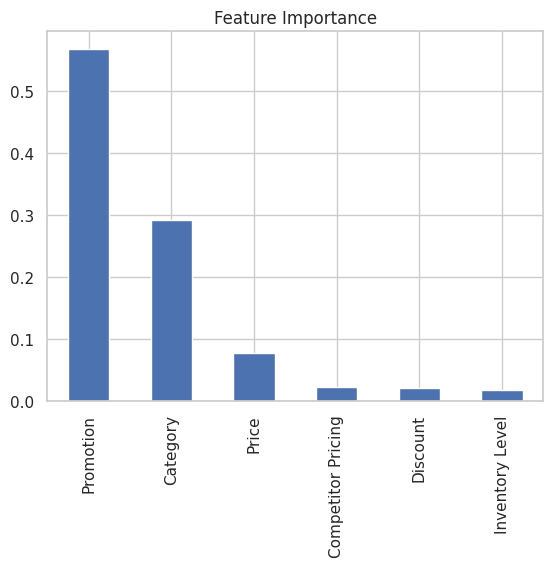

In [68]:
feature_importance.plot(kind="bar",title="Feature Importance")

In [69]:
with open("label_encoders.pkl","wb") as f:
  pickle.dump(label_encoders,f)

In [70]:
with open("xgboost_demand_model.pkl","wb") as f:
  pickle.dump(best_model,f)

In [72]:
Y_pred = best_model.predict(X_test)

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Model Evaluation")
print("-"*40)
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

Model Evaluation
----------------------------------------
MAE : 26.83
MSE : 1242.32
RMSE: 35.25
R² Score: 0.4249


In [74]:
prediction_df = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

prediction_df.head(10)

,Actual,Predicted
4744,60,67.412239
52274,123,70.995728
70321,102,96.214622
43520,40,105.714180
13128,69,90.743126
71266,138,125.846436
57757,115,128.042999
27398,121,108.435158
62097,58,59.343143
12277,56,93.712128


In [81]:
new_data = pd.DataFrame({
    'Price': [1200],
    'Discount': [10],
    'Inventory Level': [500],
    'Promotion': [1],
    'Competitor Pricing': [1150],
    'Category': [2]      # encoded value
})

prediction = best_model.predict(new_data)

print("Predicted Demand:", prediction[0])

Predicted Demand: 139.65797


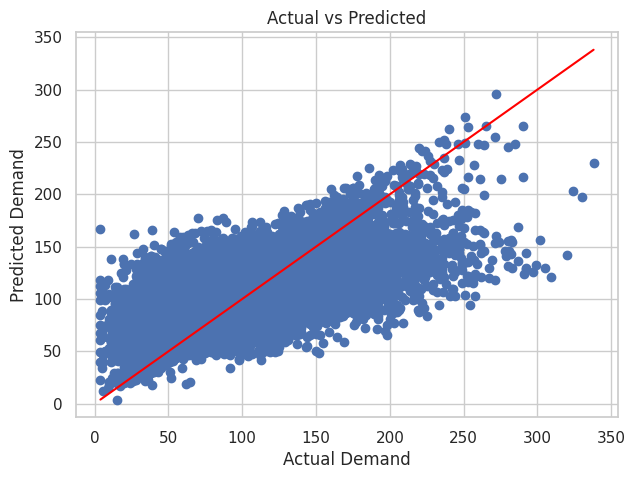

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(Y_test, Y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    color='red'
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted")
plt.show()

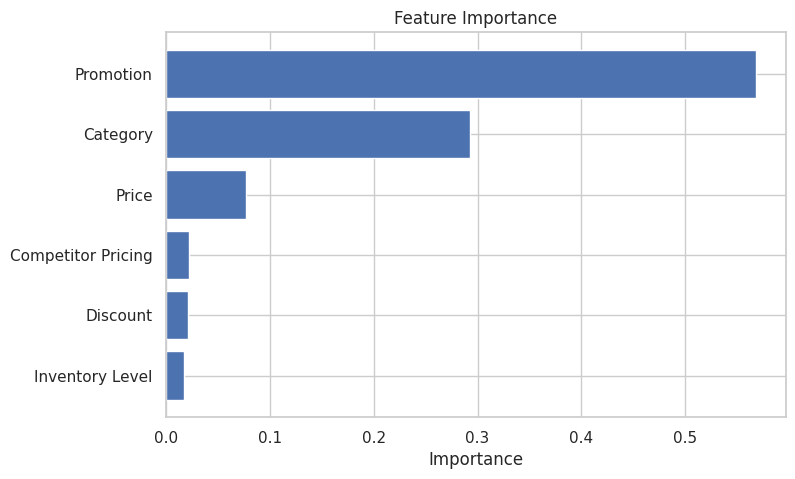

In [78]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

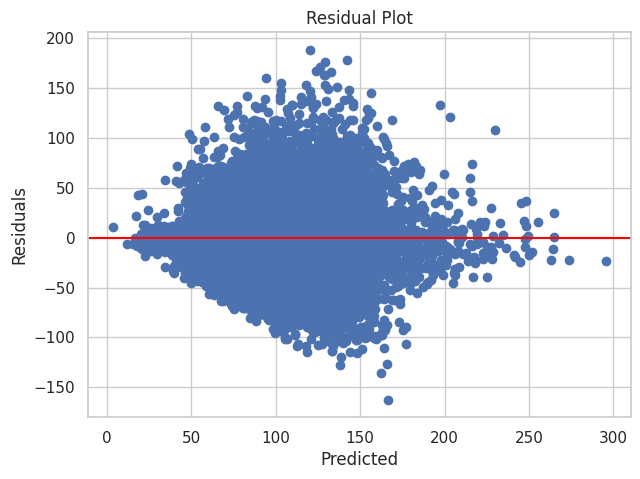

In [79]:
residuals = Y_test - Y_pred

plt.figure(figsize=(7,5))

plt.scatter(Y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()